# Связь ИИ и успеваемости студентов

Исследуем, связаны ли использование генеративного ИИ и академические результаты студентов.

## Основные вопросы
- Изменился ли GPA после семестра?
- Связано ли использование GenAI с изменением GPA?
- Отличается ли изменение GPA между студентами с высокой и низкой активностью использования AI?
- Связана ли специальность с основным способом использования AI?
- Отличается ли доля студентов с улучшением GPA между группами высокой и низкой активности AI?
- Какие факторы лучше всего объясняют изменение GPA?

In [13]:
# %pip install seaborn

In [2]:
import io
import pandas as pd
import numpy as np
from pyodide.http import open_url

## 1. Подгрузка данных

### Описание данных

Набор данных моделирует влияние ИИ на успеваемость студентов, их навыки, благополучение и риск выгорания. 


- `Major_Category` – Профиль обучения студента (STEM, Business, Humanities, Medical, Arts)
- `Year_of_Study` – Статус обучения (Freshman, Sophomore, Junior, Senior, Graduate)
- `Pre_Semester_GPA` - Средний балл в начале семестра (диапазон: ~1.18 – 4.00)
- `Post_Semester_GPA` – Средний балл в конце семестра (диапазон: ~1.00 – 4.00)

**Как пользуются ИИ**

- `Weekly_GenAI_Hours` – Среднее число число часов использования ИИ в неделю (0 – 40 часов)
- `Primary_Use_Case` – Для чего использует ИИ (Copywriting/Drafting, Summarizing_Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation)
- `Prompt_Engineering_Skill` – Самооценка навыка написания промптов (Beginner, Intermediate, Advanced)
- `Tool_Diversity` – Сколько разных ИИ использует (1–5)
- `Paid_Subscription` – Есть ли платная подписка (Да = True / Нет = False)

**Как учится**

- `Traditional_Study_Hours` – Сколько часов в неделю посвящает традиционной (без ИИ) учёбе (1 – ~36 часов)
- `Perceived_AI_Dependency` – Восприятие студентом собственной зависимости от ИИ по шкале от 1 (минимально) до 10 (максимально)

**Отношение Университета к ИИ**

- `Institutional_Policy` – Отношение Университета к использованию ИИ (Нужно отмечать = Allowed_With_Citation, Запрещается = Strictly_Ban, Поощряется = Actively_Encouraged)

**Благополучие студента**

- `Anxiety_Level_During_Exams` – Оценка уровня волнения перед экзаменом (от 1 до 10)
- `Skill_Retention_Score` – Уровень остаточных знаний студента (0–100)
- `Burnout_Risk_Level` – Как оценивает риск выгорания (Низкий = Low, Средний = Medium, Высокий = High)


In [3]:
url = "https://raw.githubusercontent.com/vtorygit/hypostats/refs/heads/main/data/ai_and_students"
csv_data = open_url(url).read()
df = pd.read_csv(io.StringIO(csv_data))

В данных 50 тыс. наблюдений и 16 переменных

In [8]:
df.shape

(50000, 16)

Посмотрим на первые несколько строк данных

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


Посмотрим на типы данных и проверим, что всё подгрузилось верно

In [9]:
df.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

## 2. Базовая обработка данных

Проверяем на пропуски – их нет

In [10]:
df.isna().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64



Посмотрим на значения числовых переменных:

- среднее (mean)
- стандартное отклонение (std)
- минимум (min) и максимум (max)

так мы можем понять, вокруг каких значений сосредоточены данные и насколько они отличаются, а по тому, где относительно минимума и максимума находится среднее можем понять, есть ли перевес в сторону больших или меньших значений

In [6]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


Посмотрим на категории

In [7]:
# список категориальных переменных
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

categorical_columns

Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='object')

Командой ниже можем вывести уникальные значения конкретной переменной и частоту их встречаемости

In [8]:
df["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Запуская команду в цикле мы можем получить сводку по всем переменным

In [9]:
for column in categorical_columns:
    print("=" * 50)
    print(column)
    print(df[column].value_counts())
    print()

Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

Paid_Subscription
Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

Burnout_Risk_Level
Burnout_Risk_Level
Medium    21144
Low  

## 3. Подготовка данных

Создаём новые признаки, необходимые для ответа на исследовательские вопросы.

In [10]:
df["GPA_Change"] = (
    df["Post_Semester_GPA"]
    - df["Pre_Semester_GPA"]
)

In [11]:
df["Improved_GPA"] = (
    df["GPA_Change"] > 0
)

## 4. Начало анализа

Перед началом анализа стоит изучить переменные, с которыми будет осуществляться работа. Визуализации – удобный способ это сделать.

### GPA

Изменение среднего балла (`GPA_change`) является целевой переменной, поэтому целесообразно начать визуальное изучение данных с неё. Построим распределение и воспользуемся для этого гистограммой.

In [ ]:
# %pip install seaborn # раскомментировать, если команда ниже не работает

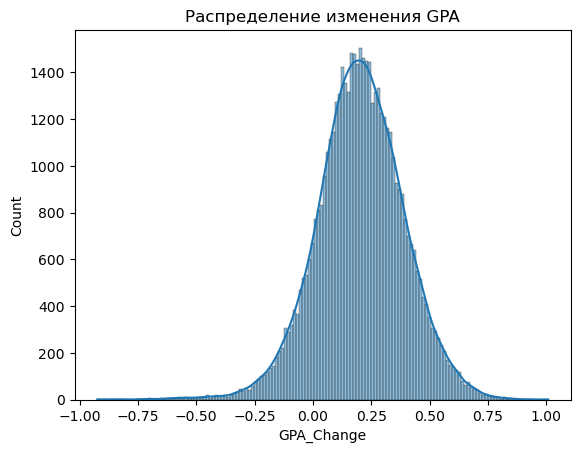

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["GPA_Change"], kde=True)
plt.title("Распределение изменения GPA")
plt.show()

Получаем колокол, который немного смещён в сторону больших значений (с левой стороны видим длинный хвост низкочастотных значений).

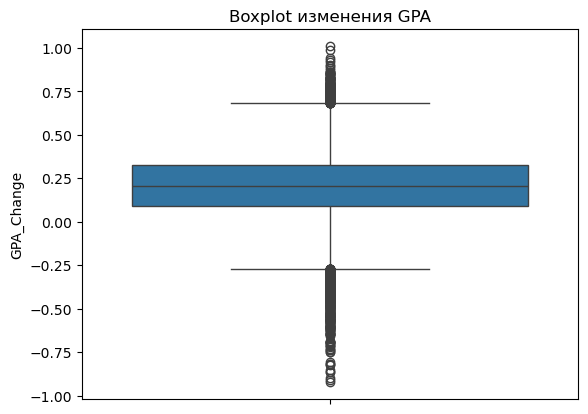

In [15]:
sns.boxplot(y=df["GPA_Change"])
plt.title("Boxplot изменения GPA")
plt.show()

Из диаграммы "ящик с усами" мы видим большое число выбросов (обозначаются точками на графике). Посчитаем границы нормальных значений.

In [16]:
Q1 = df["GPA_Change"].quantile(0.25)
Q3 = df["GPA_Change"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Нижняя граница:", round(lower, 3))
print("Верхняя граница:", round(upper, 3))

Нижняя граница: -0.27
Верхняя граница: 0.682


Найдём выбросы и поймём масштабы проблемы

In [17]:
outliers = df[
    (df["GPA_Change"] < lower)
    | (df["GPA_Change"] > upper)
]

print("Число выбросов:", len(outliers))

Число выбросов: 760


А что вообще относится к выбросам? Что это за наблюдения?

In [18]:
outliers[[
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "GPA_Change"
]]

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change
13,3.225,3.935,0.710
25,3.308,4.000,0.692
109,2.379,3.090,0.711
245,2.810,2.358,-0.452
321,3.244,3.933,0.689
...,...,...,...
49726,3.238,3.940,0.702
49735,2.760,3.451,0.691
49807,2.076,1.669,-0.407
49828,3.500,2.910,-0.590


В датасете найдено 760 выбросов. Их доля составляет 1.5%. Если мы смотрим на сами значения, то увидим, что изменение оценки, которые по статистике стоит считать выбросом, на самом деле более чем реально. Оснований удалять наблюдения нет, поэтому дальнейший анализ выполняется на полном наборе данных.

### Посмотрим на данные в целом

Помимо просмотра отдельных перменных полезно смотреть на данные целиком. Вот как мы можем это сделать

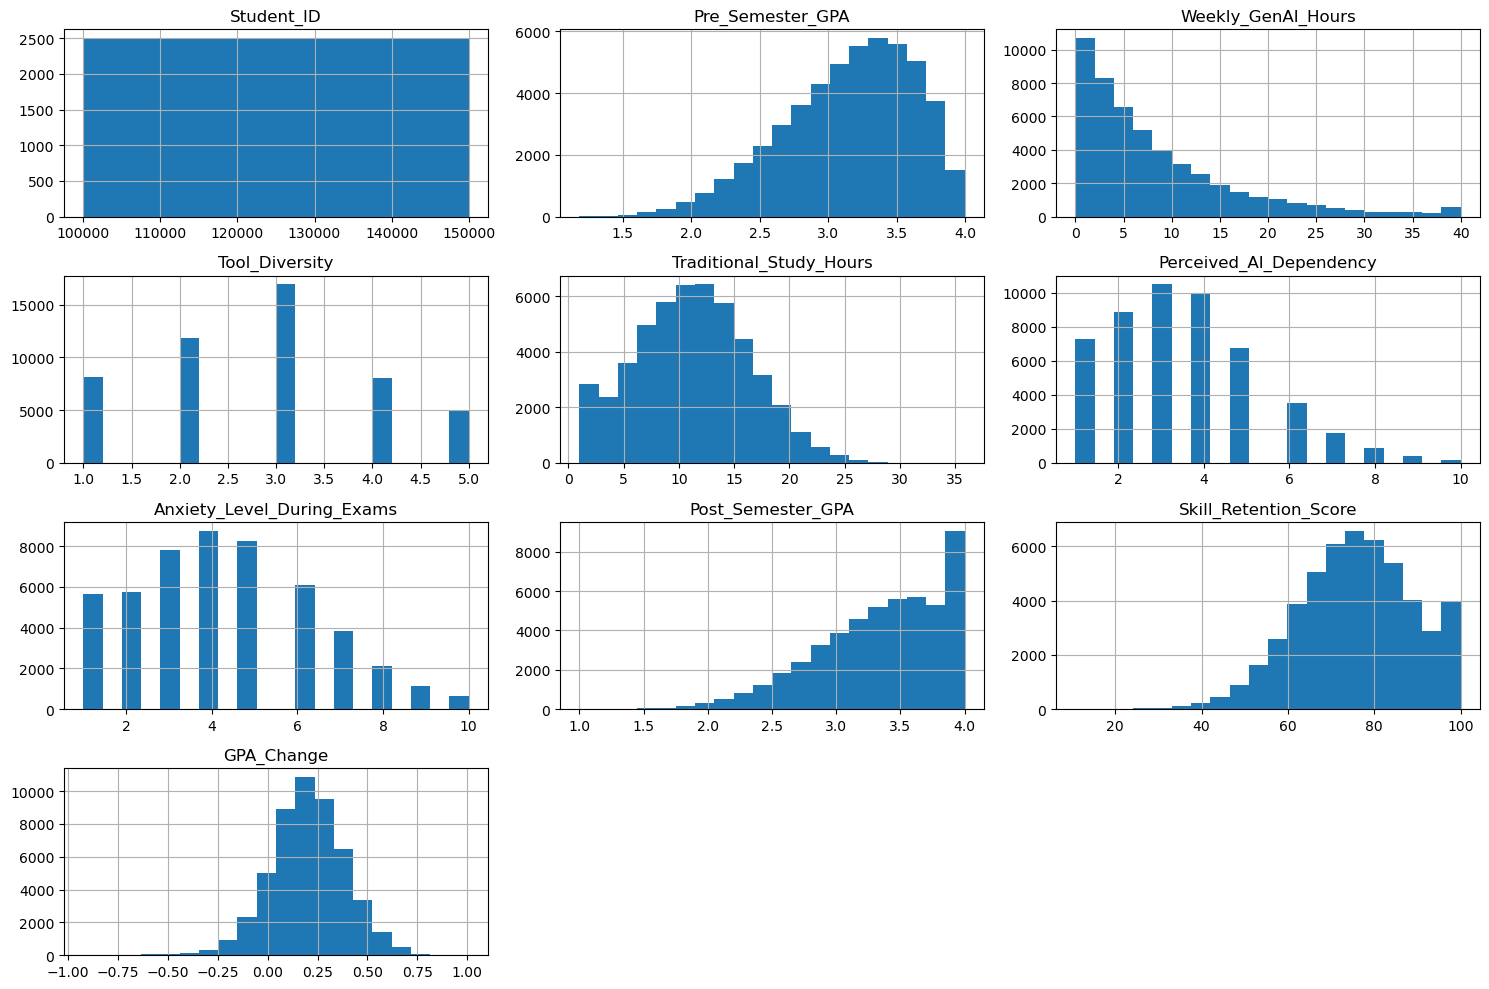

In [20]:
numeric_columns = df.select_dtypes(
    include="number"
).columns

df[numeric_columns].hist(
    figsize=(15, 10),
    bins=20
)

plt.tight_layout()
plt.show()

Другая диаграмма – pairplot. Из неё сразу видно потенциальные связи. По диагонали видим распределение каждой из переменных, которые включили в визуализацию.

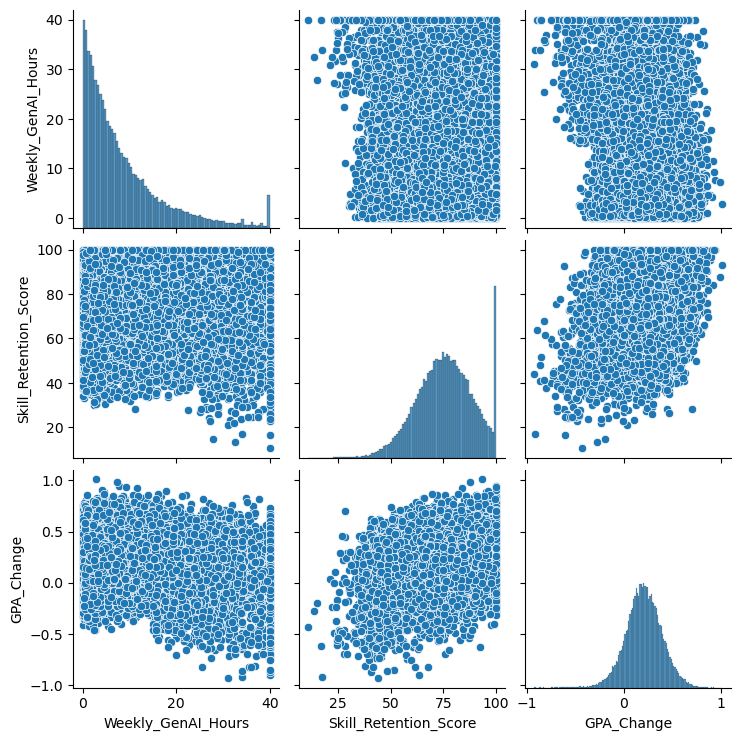

In [19]:
selected = [
    "Weekly_GenAI_Hours",
    "Skill_Retention_Score",
    "GPA_Change"
]

sns.pairplot(
    df[selected]
)

По категориальным переменным можно посмотреть на столбчатые диаграммы (bar chart) – они отражают частоту встречаемости каждой из категории. Эти данные мы видели в сводке выше, а визуализация позволяет увить соотношение частот наглядно.

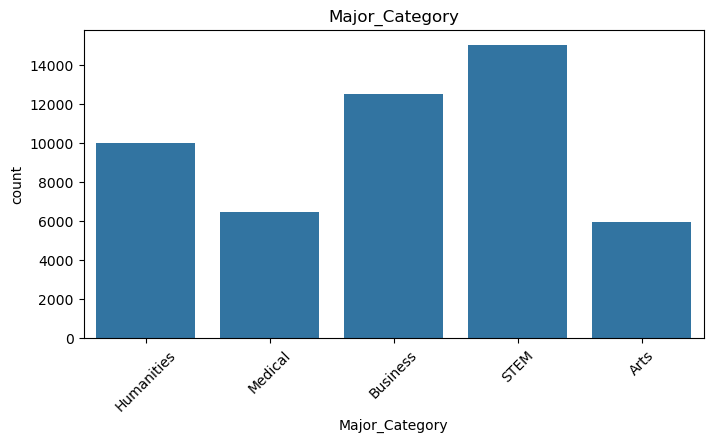

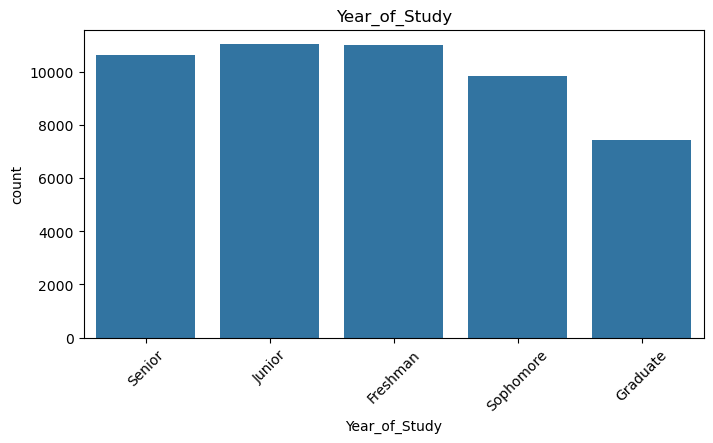

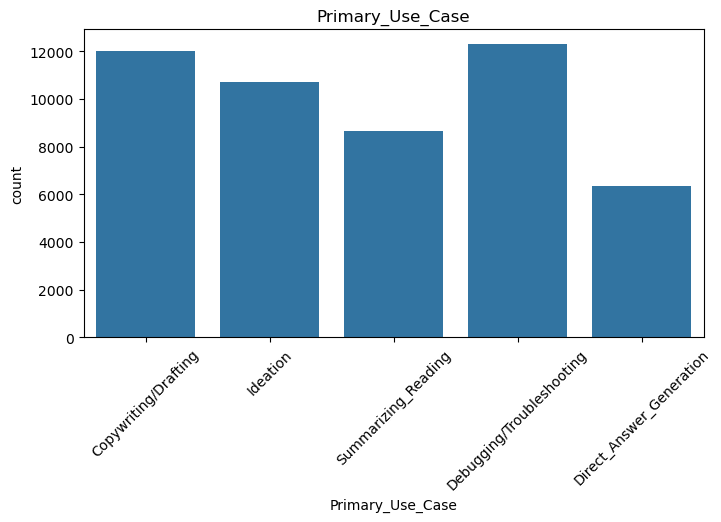

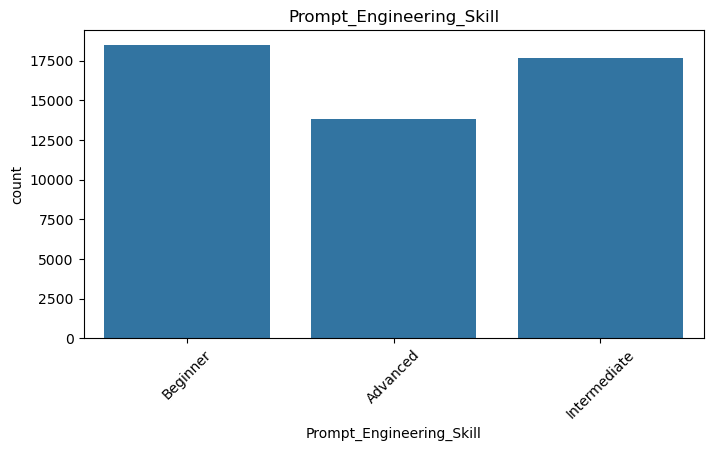

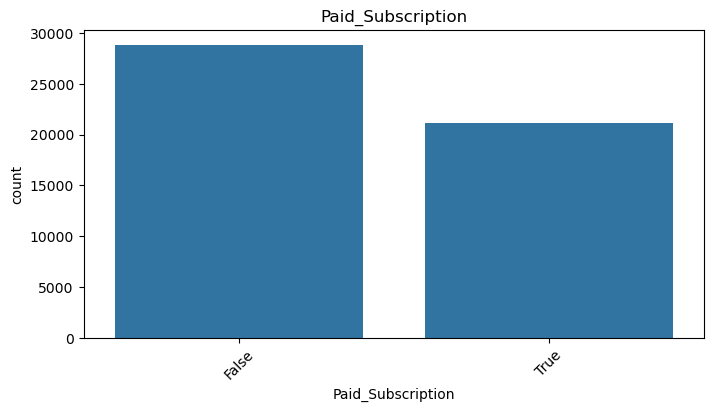

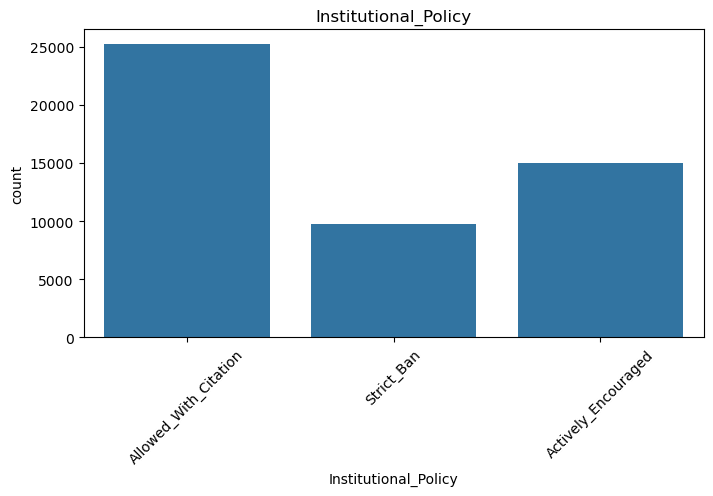

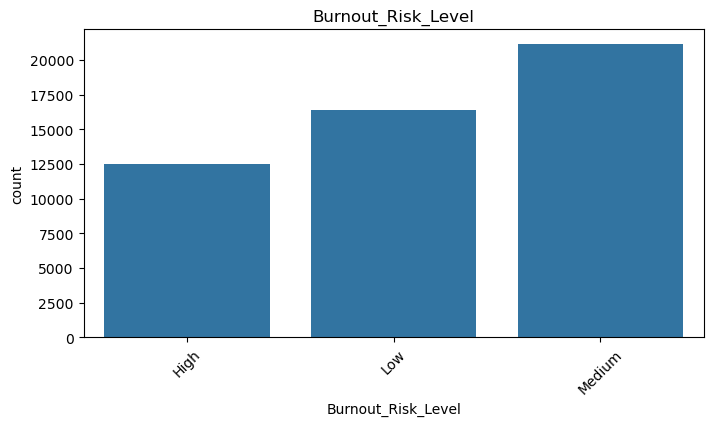

In [21]:
for column in categorical_columns:

    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()

## 6. Отвечаем на исследовательские вопросы

### Вопрос 1. Изменился ли GPA после семестра?

Переменные: `Pre_Semester_GPA`, `Post_Semester_GPA`

Тест: парный t-тест

В нашем датасете есть связанные выборки: у одних и тех же студентов измеряли средний балл в начале семестра и по его итогам. Используем эти данные для того чтобы понять, произошли изменения и были ли они значимы.

### Посмотрим на средние значения

Рассчитаем простые выборочные средние. Видим, что в начале семестра средний балл по всем студентам составлят 3.14, а в конце – 3.34. Кажется, изменение есть! 

In [22]:
df["Pre_Semester_GPA"].mean()

np.float64(3.14610234)

In [23]:
df["Post_Semester_GPA"].mean()

np.float64(3.34929942)

Прежде чем перейти к стат. тесту, посмотрим на то, как поменялись GPA для отдельных студентов

In [24]:
df["GPA_Change"] = (
    df["Post_Semester_GPA"]
    - df["Pre_Semester_GPA"]
)

df["GPA_Status"] = np.where(
    df["GPA_Change"] > 0,
    "Вырос",
    np.where(
        df["GPA_Change"] < 0,
        "Снизился",
        "Не изменился"
    )
)

Посмотрим, сколько ответов попало в каждую категорию

In [25]:
gpa_summary = (
    df["GPA_Status"]
    .value_counts()
    .reset_index()
)

gpa_summary.columns = [
    "Изменение GPA",
    "Число студентов"
]

gpa_summary["Доля, %"] = (
    gpa_summary["Число студентов"]
    / len(df)
    * 100
).round(1)

gpa_summary

,Изменение GPA,Число студентов,"Доля, %"
0,Вырос,43759,87.5
1,Снизился,6192,12.4
2,Не изменился,49,0.1


А что в реальности происходит в данных? Посмотрим на 10 наблюдений

In [26]:
df[
    [
        "Student_ID",
        "Pre_Semester_GPA",
        "Post_Semester_GPA",
        "GPA_Status"
    ]
].head(10)

,Student_ID,Pre_Semester_GPA,Post_Semester_GPA,GPA_Status
0,100001,2.418,2.393,Снизился
1,100002,3.821,3.696,Снизился
2,100003,3.398,3.499,Вырос
3,100004,3.789,4.000,Вырос
4,100005,3.635,3.798,Вырос
5,100006,3.449,3.666,Вырос
6,100007,3.622,4.000,Вырос
7,100008,2.746,2.965,Вырос
8,100009,3.420,3.396,Снизился
9,100010,3.046,2.978,Снизился


Запускаем стат. тест!

In [27]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(
    df["Pre_Semester_GPA"],
    df["Post_Semester_GPA"]
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-статистика: -242.726
p-value: 0.00000


Наконец, посмотрев на данные и сделав стат. тест мы можем сказать, что **средний балл вырос**.

### Вопрос 2. Связано ли количество часов использования GenAI с изменением GPA?

Переменные: `Weekly_GenAI_Hours`, `GPA_Change`

Подход: визуальный анализ + корреляция Пирсона

Мы уже выяснили, что GPA в среднем вырос. Далее мы хотим посмотреть на это в контексте использования ИИ.

**Визуальный анализ**

Для начала построим диаграмму рассеивания. Каждая точка соответствует одному студенту. По горизонтальной оси отложено количество часов использования GenAI в неделю, по вертикальной — изменение GPA за семестр.
Если между переменными существует связь, на графике должен появиться некоторый тренд: например, при увеличении числа часов использования AI точки будут систематически подниматься или опускаться.

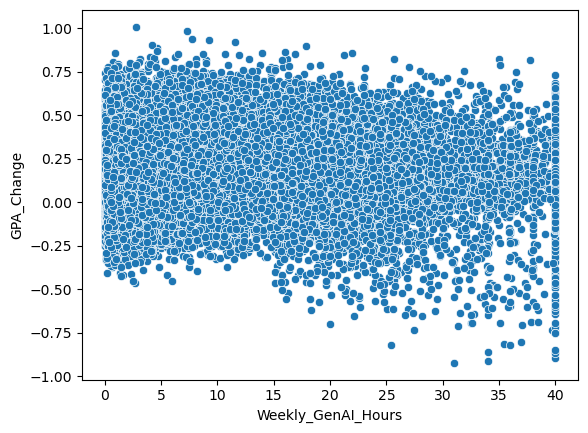

In [37]:
sns.scatterplot(
    data=df,
    x="Weekly_GenAI_Hours",
    y="GPA_Change"
)
plt.show()

**Коэффициент корреляции Пирсона**

На больших выборках визуально оценить связь бывает сложно. Поэтому дополнительно рассчитаем коэффициент корреляции Пирсона.

Коэффициент корреляции принимает значения от -1 до 1:

- значения около 1 говорят о сильной положительной связи;
- значения около -1 говорят о сильной отрицательной связи;
- значения около 0 говорят об отсутствии линейной связи.


Помимо самого коэффициента рассчитывается p-value, которое позволяет проверить статистическую значимость обнаруженной связи.

In [38]:
corr, p_value = stats.pearsonr(
    df["Weekly_GenAI_Hours"],
    df["GPA_Change"]
)

print(f"Корреляция: {corr:.3f}")
print(f"p-value: {p_value:.5f}")

Корреляция: -0.046
p-value: 0.00000


Полученный коэффициент корреляции очень близок к нулю. Это означает, что линейная связь между количеством часов использования ИИ и изменением GPA практически отсутствует. При этом p-value оказался значительно меньше 0.05. Следовательно, формально связь статистически значима и она отрицательна.

Подобная ситуация часто встречается на больших выборках: статистический тест способен обнаружить даже очень слабые зависимости. Поэтому в прикладном анализе всегда важно смотреть не только на p-value, но и на величину самого коэффициента корреляции.

### Вопрос 3. Отличается ли изменение GPA между студентами с высокой и низкой активностью использования AI?

Тест: t-тест для независимых выборок

Корреляция показывает наличие или отсутствие линейной связи между двумя числовыми переменными. Однако нас может интересовать и другой вопрос.

Разделим студентов на две группы:
- активно использующие ИИ
- менее активно использующие ИИ

После этого сравним среднее изменение GPA в этих группах. Для разделения используем медианное значение количества часов использования AI. Студенты выше медианы попадут в группу высокой активности, остальные — в группу низкой активности.

In [30]:
df["High_AI_Use"] = (
    df["Weekly_GenAI_Hours"] >= df["Weekly_GenAI_Hours"].median()
)

Сначала посмотрим на описательные статистики групп. Таблица позволяет увидеть размер групп, среднее изменение GPA и разброс значений внутри каждой группы.
После этого построим boxplot.

In [31]:
df.groupby("High_AI_Use")["GPA_Change"].agg(
    ["count", "mean", "std", "median"]
)

,count,mean,std,median
High_AI_Use,,,,
False,24992,0.196766,0.175867,0.1935
True,25008,0.209624,0.197657,0.2140


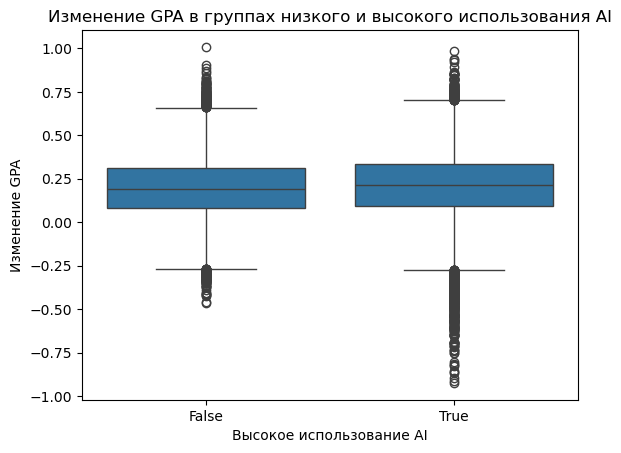

In [32]:
sns.boxplot(
    data=df,
    x="High_AI_Use",
    y="GPA_Change"
)

plt.title("Изменение GPA в группах низкого и высокого использования AI")
plt.xlabel("Высокое использование AI")
plt.ylabel("Изменение GPA")
plt.show()

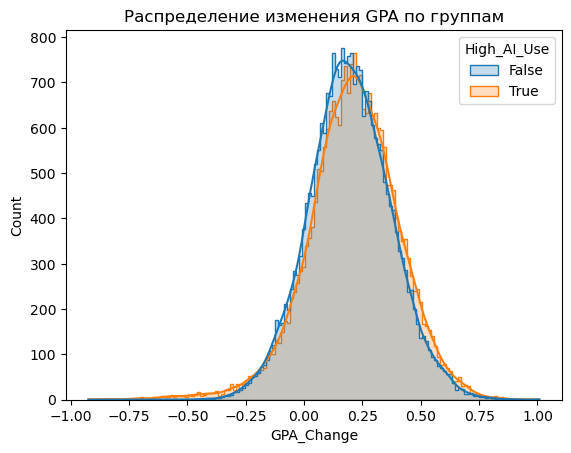

In [33]:
sns.histplot(
    data=df,
    x="GPA_Change",
    hue="High_AI_Use",
    kde=True,
    element="step"
)

plt.title("Распределение изменения GPA по группам")
plt.show()

На графике показано распределение изменения GPA в двух группах. Если группы действительно различаются, медианы и распределения должны заметно отличаться друг от друга.
Для формальной проверки используем t-тест для независимых выборок.

In [29]:
high = df[df["High_AI_Use"]]["GPA_Change"]
low = df[~df["High_AI_Use"]]["GPA_Change"]

t_stat, p_value = stats.ttest_ind(
    high,
    low,
    equal_var=False
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

t-статистика: 7.684
p-value: 0.00000


Полученное p-value значительно меньше уровня значимости 0.05, следовательно, нулевая гипотеза о равенстве средних отвергается. Среднее изменение GPA различается между группами студентов с высокой и низкой активностью использования AI.

### Вопрос 4. Связана ли специальность с основным способом использования AI?

Переменные: `Major_Category`, `Primary_Use_Case`

Тест: хи-квадрат

До этого момента мы работали с числовыми переменными. Теперь рассмотрим две категориальные переменные.
Нас интересует следующий вопрос: используют ли студенты разных специальностей генеративный ИИ одинаковым образом или предпочтения различаются?

Для ответа построим таблицу сопряжённости.

In [34]:
table = pd.crosstab(
    df["Major_Category"],
    df["Primary_Use_Case"]
)

table

Primary_Use_Case,Copywriting/Drafting,Debugging/Troubleshooting,Direct_Answer_Generation,Ideation,Summarizing_Reading
Major_Category,,,,,
Arts,2601,821,823,845,843
Business,1608,1640,1649,6003,1638
Humanities,5188,1162,1139,1251,1254
Medical,799,879,866,832,3100
STEM,1815,7793,1863,1790,1798


Каждая строка соответствует специальности, а каждый столбец — одному из способов использования AI.
По таблице уже можно заметить определённые различия между группами. Чем сильнее отличаются распределения по строкам, тем выше вероятность существования статистической связи между переменными.

Однако визуального анализа недостаточно, поэтому воспользуемся критерием хи-квадрат.

In [35]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"Хи-квадрат: {chi2:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"Степени свободы: {dof}")

Хи-квадрат: 22141.285
p-value: 0.00000
Степени свободы: 16


Полученное p-value значительно меньше 0.05. Следовательно, нулевая гипотеза о независимости переменных отвергается. Специальность студента и основной способ использования GenAI связаны между собой.

### Вопрос 5. Отличается ли доля студентов с улучшением GPA между группами высокой и низкой активности AI?

Переменные: `Improved_GPA`, `High_AI_Use`

Тест: Z-тест двух долей

В предыдущем анализе мы сравнивали среднее изменение GPA. Теперь сформулируем более простой вопрос: отличается ли вероятность улучшения GPA между группами?

Сравним доли студентов с улучшением GPA в группах высокой и низкой активности использования AI.

In [36]:
prop_table = pd.crosstab(
    df["High_AI_Use"],
    df["Improved_GPA"],
    normalize="index"
) * 100

prop_table.round(1)

Improved_GPA,False,True
High_AI_Use,,
False,12.6,87.4
True,12.4,87.6


Для визуального сравнения построим столбчатую диаграмму.

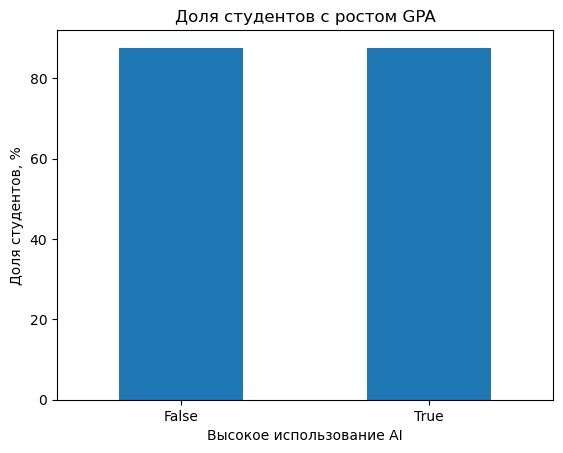

In [37]:
prop_table[True].plot(kind="bar")

plt.title("Доля студентов с ростом GPA")
plt.xlabel("Высокое использование AI")
plt.ylabel("Доля студентов, %")
plt.xticks(rotation=0)
plt.show()

На графике показана доля студентов, улучшивших GPA, в каждой группе. Мы видим, что графики практически идентичный. 


Однако даже заметные различия на графике могут возникать случайно. Поэтому выполним Z-тест для сравнения двух долей.

In [38]:
from statsmodels.stats.proportion import proportions_ztest

table = pd.crosstab(
    df["High_AI_Use"],
    df["Improved_GPA"]
)

success = table[True].values
nobs = table.sum(axis=1).values

z_stat, p_value = proportions_ztest(success, nobs)

print(f"Z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")

Z-статистика: -0.582
p-value: 0.56071


Полученное p-value значительно превышает уровень значимости 0.05, следовательно, оснований отвергать нулевую гипотезу нет. Доля студентов с улучшением GPA не отличается между группами высокой и низкой активности использования AI.

### Вопрос 6. Какие факторы лучше всего объясняют изменение GPA?

Подход: корряляционный анализ + регрессия

Целевая переменная: `GPA_Change`

Предикторы: `Weekly_GenAI_Hours`, `Skill_Retention_Score`, `Burnout_Level`, `Anxiety_Level`

На предыдущих шагах мы рассматривали факторы по отдельности, однако в реальных исследованиях обычно необходимо оценивать влияние нескольких факторов одновременно. Для этого используется регрессионный анализ.

#### Корреляционная матрица

Перед построением модели посмотрим на корреляционную матрицу.

In [39]:
selected_features = [
    "Weekly_GenAI_Hours",
    "Skill_Retention_Score",
    "GPA_Change"
]

df[selected_features].corr().round(3)

,Weekly_GenAI_Hours,Skill_Retention_Score,GPA_Change
Weekly_GenAI_Hours,1.000,-0.118,-0.046
Skill_Retention_Score,-0.118,1.000,0.196
GPA_Change,-0.046,0.196,1.000


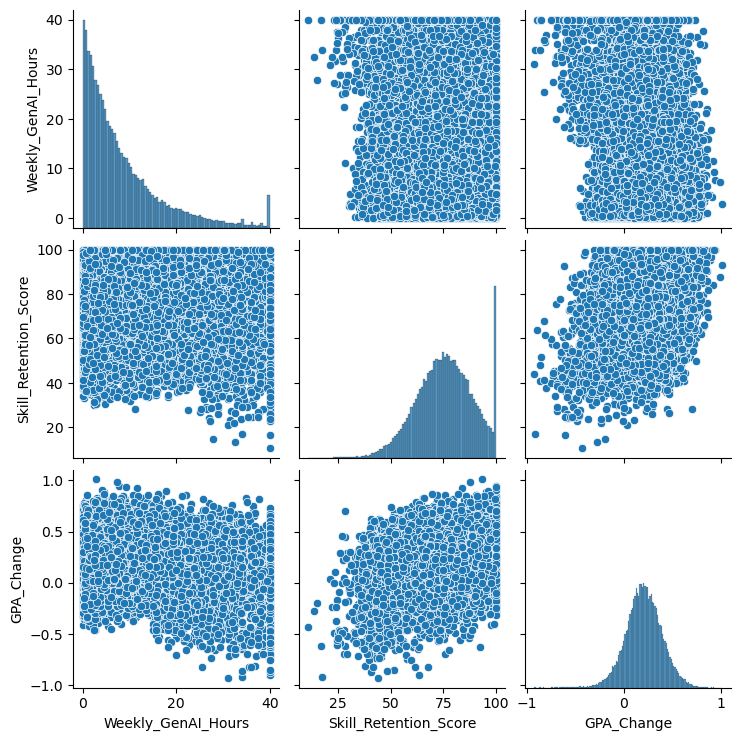

In [40]:
sns.pairplot(
    df[selected_features]
)
plt.show()

Корреляционная матрица позволяет быстро оценить направления и силу связей между всеми числовыми переменными сразу. Мы видим, что для выбранных переменных корреляции небольшие, но давайте попробуем построить модель посмотреть, что из этого выйдет – представим, что мы решили использовать именно эти переменные, опираясь на теорию и чьи-то исследования

#### Регрессия

После предварительного анализа построим линейную регрессию. Модель попытается объяснить изменение GPA через выбранные факторы.

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = [
    "Weekly_GenAI_Hours",
    "Skill_Retention_Score"
]

X = df[features]
y = df["GPA_Change"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)


**Объяснительная способность модели**

In [44]:
print("R² =", round(r2_score(y, pred), 3))

R² = 0.039


Значение R² низкое. Это означает, что выбранные признаки объясняют только небольшую часть различий в изменении GPA.

Коэффициенты показывают направление связи: положительный коэффициент связан с ростом GPA_Change, отрицательный — со снижением. Однако по размеру коэффициентов видно, что вклад признаков небольшой.

In [46]:
coef = coef.sort_values(
    "Коэффициент",
    key=abs,
    ascending=False
)

coef

,Признак,Коэффициент
1,Skill_Retention_Score,0.002721
0,Weekly_GenAI_Hours,-0.000536


Полученные коэффициенты показывают направление влияния факторов.
Положительный коэффициент означает, что увеличение признака связано с ростом GPA_Change.
Отрицательный коэффициент означает обратную зависимость.

In [47]:
results = pd.DataFrame({
    "Фактическое GPA_Change": y,
    "Предсказанное GPA_Change": pred
})

results.head(10)

,Фактическое GPA_Change,Предсказанное GPA_Change
0,-0.025,0.224172
1,-0.125,0.189680
2,0.101,0.191236
3,0.211,0.173498
4,0.163,0.268580
5,0.217,0.177356
6,0.378,0.169579
7,0.219,0.230138
8,-0.024,0.151990
9,-0.068,0.227965


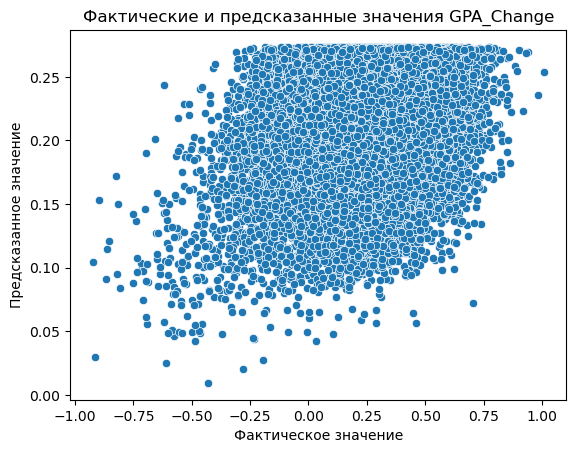

In [48]:
sns.scatterplot(
    x=y,
    y=pred
)

plt.title("Фактические и предсказанные значения GPA_Change")
plt.xlabel("Фактическое значение")
plt.ylabel("Предсказанное значение")
plt.show()

### Исправляем модель

Теперь пойдём от данных

In [49]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

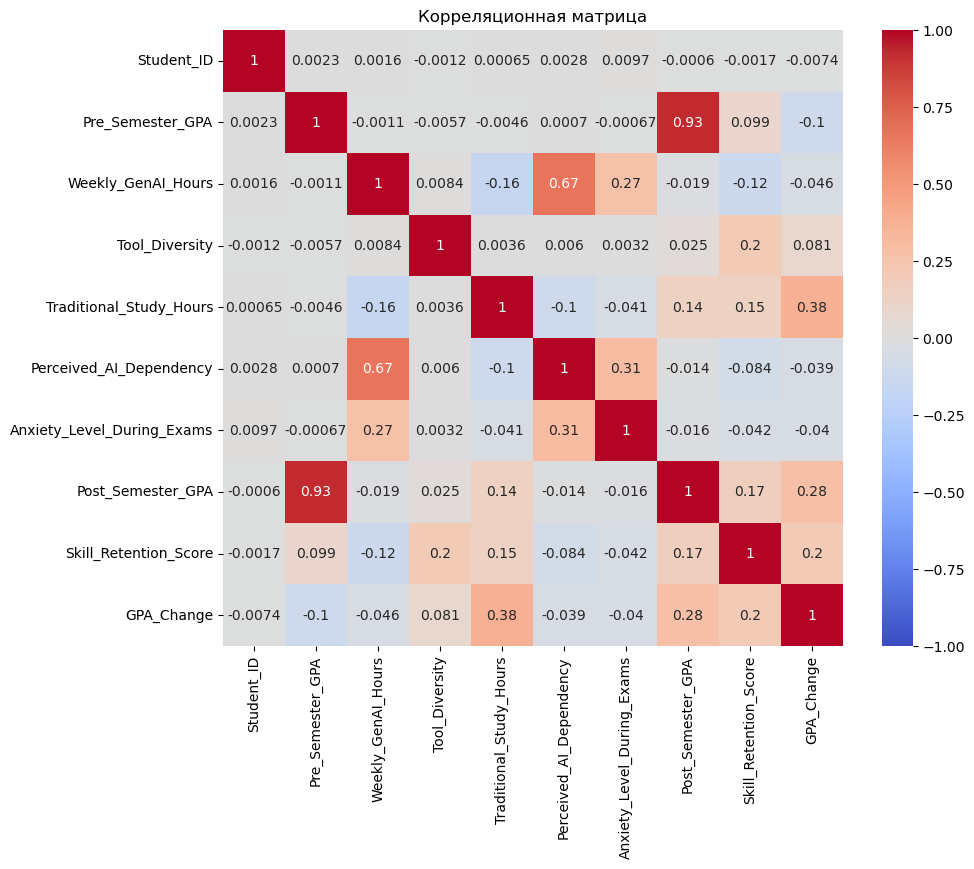

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица")
plt.show()

Мы видим, что с нашей целевой переменной больше всего связано Traditional_Study_Hours, также можно попробовать оставить Skill_Retention_Score. Также можно попробовать включить в переменную High_AI_Use.

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

features = [
    "Traditional_Study_Hours",
    "Skill_Retention_Score",
    "High_AI_Use"
]

X = df[features]
y = df["GPA_Change"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

print("R² =", round(r2_score(y, pred), 3))

R² = 0.168


Коэффициент подрос! Пусть он не высокий, но это уже что-то. Давайте посмотрим на саму модель.

In [63]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ["Traditional_Study_Hours", "Skill_Retention_Score", "High_AI_Use"]

# --- Защита от ошибок: переводим данные в числа ---
# Если в High_AI_Use текст (например, 'Yes'/'No'), превращаем в 1 и 0
if df["High_AI_Use"].dtype == "object":
    # Замените 'Yes' на то текстовое значение, которое означает "высокое использование ИИ"
    df["High_AI_Use"] = (df["High_AI_Use"] == "Yes").astype(int)

# Явно принудительно переводим все выбранные колонки в float
X = df[features].astype(float)
y = df["GPA_Change"].astype(float)
# --------------------------------------------------

model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

# Вычисления для таблицы
n, p = X.shape
X_design = np.hstack([np.ones((n, 1)), X.values])

residuals = y.values - pred
residual_variance = np.sum(residuals**2) / (n - p - 1)

# Теперь здесь не будет ошибки UFuncTypeError
covariance_matrix = np.linalg.inv(X_design.T @ X_design) * residual_variance
standard_errors = np.sqrt(np.diagonal(covariance_matrix))

all_coefficients = np.append(model.intercept_, model.coef_)
t_statistics = all_coefficients / standard_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_statistics), df=n - p - 1))

summary_df = pd.DataFrame(
    {
        "Coefficient": all_coefficients,
        "Std Error": standard_errors,
        "t-value": t_statistics,
        "p-value": p_values,
    },
    index=["Intercept"] + features,
)

print("-" * 60)
print("REGRESSION MODEL SUMMARY")
print("-" * 60)
print(summary_df.round(4))
print("-" * 60)
print("R² =", round(r2_score(y, pred), 3))
print("MSE =", round(mean_squared_error(y, pred), 4))
print("-" * 60)


------------------------------------------------------------
REGRESSION MODEL SUMMARY
------------------------------------------------------------
                         Coefficient  Std Error  t-value  p-value
Intercept                    -0.1127     0.0046 -24.2735      0.0
Traditional_Study_Hours       0.0132     0.0002  87.6498      0.0
Skill_Retention_Score         0.0020     0.0001  34.7967      0.0
High_AI_Use                   0.0290     0.0015  18.8963      0.0
------------------------------------------------------------
R² = 0.168
MSE = 0.0292
------------------------------------------------------------
